# Spotify Music Data

This dataset consists of ~600 songs that were in the top songs of the year from 2010 to 2019 (as measured by Billboard). You can explore interesting song data pulled from [Spotify](http://organizeyourmusic.playlistmachinery.com/#) such as the beats per minute, amount of spoken words, loudness, and energy of every song.

In [50]:
suppressPackageStartupMessages(library(tidyverse))

spotify = read_csv('data/spotify_top_music.csv', show_col_types = FALSE)
spotify

title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78
Baby,Justin Bieber,canadian pop,2010,65,86,73,-5,11,54,214,4,14,77
Dynamite,Taio Cruz,dance pop,2010,120,78,75,-4,4,82,203,0,9,77
Secrets,OneRepublic,dance pop,2010,148,76,52,-6,12,38,225,7,4,77
Empire State of Mind (Part II) Broken Down,Alicia Keys,hip pop,2010,93,37,48,-8,12,14,216,74,3,76


## Data dictionary

|    | Variable   | Explanation                                                |
|---:|:-----------|:-----------------------------------------------------------|
|  0 | title      | The title of the song                                      |
|  1 | artist     | The artist of the song                                     |
|  2 | top genre  | The genre of the song                                      |
|  3 | year       | The year the song was in the Billboard                     |
|  4 | bpm        | Beats per minute: the tempo of the song                    |
|  5 | nrgy       | The energy of the song: higher values mean more energetic (fast, loud)  |
|  6 | dnce       | The danceability of the song: higher values mean it's easier to dance to  |
|  7 | dB         | Decibel: the loudness of the song  |
|  8 | live       | Liveness: likeliness the song was recorded with a live audience  |
|  9 | val        | Valence: higher values mean a more positive sound (happy, cheerful) |
| 10 | dur        | The duration of the song |
| 11 | acous      | The acousticness of the song: likeliness the song is acoustic|
| 12 | spch       | Speechines: higher values mean more spoken words |
| 13 | pop        | Popularity: higher values mean more popular|

[Source](https://www.kaggle.com/leonardopena/top-spotify-songs-from-20102019-by-year) of dataset.


In [51]:
# Load necessary libraries
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(gridExtra))

# Read the dataset
spotify = read_csv('data/spotify_top_music.csv', show_col_types = FALSE)

# Analyze the most popular genre
genre_popularity = spotify %>%
  group_by(`top genre`) %>%
  summarise(count = n()) %>%
  arrange(desc(count))

# Identify the most popular genre
most_popular_genre = genre_popularity %>%
  slice(1) %>%
  pull(`top genre`)

# Display the most popular genre
most_popular_genre


[1] "dance pop"

Dance pop is the most popular genre! 

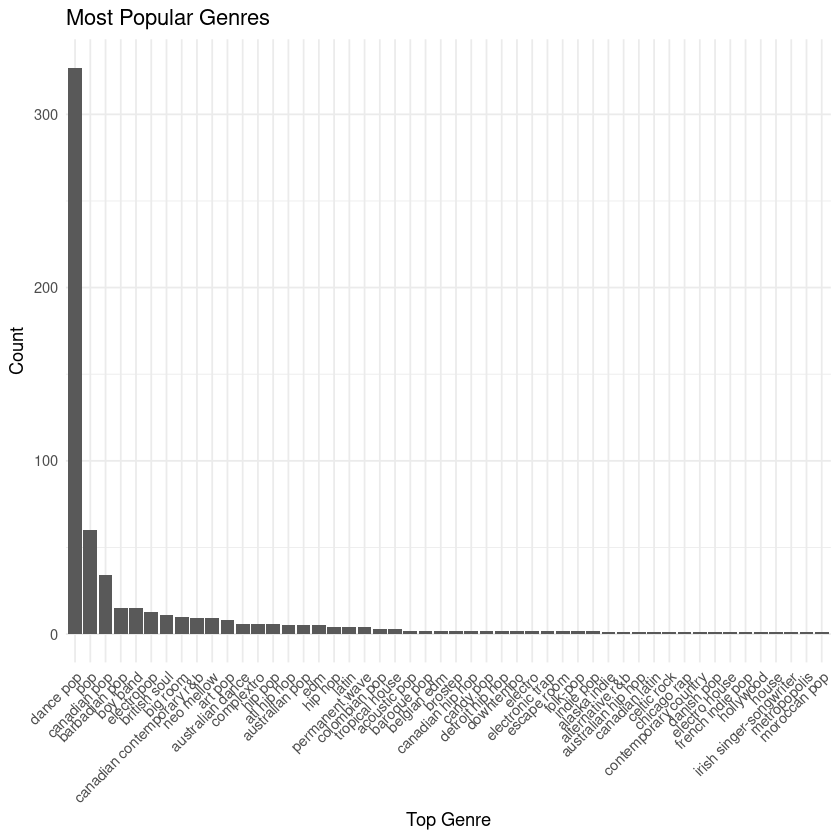

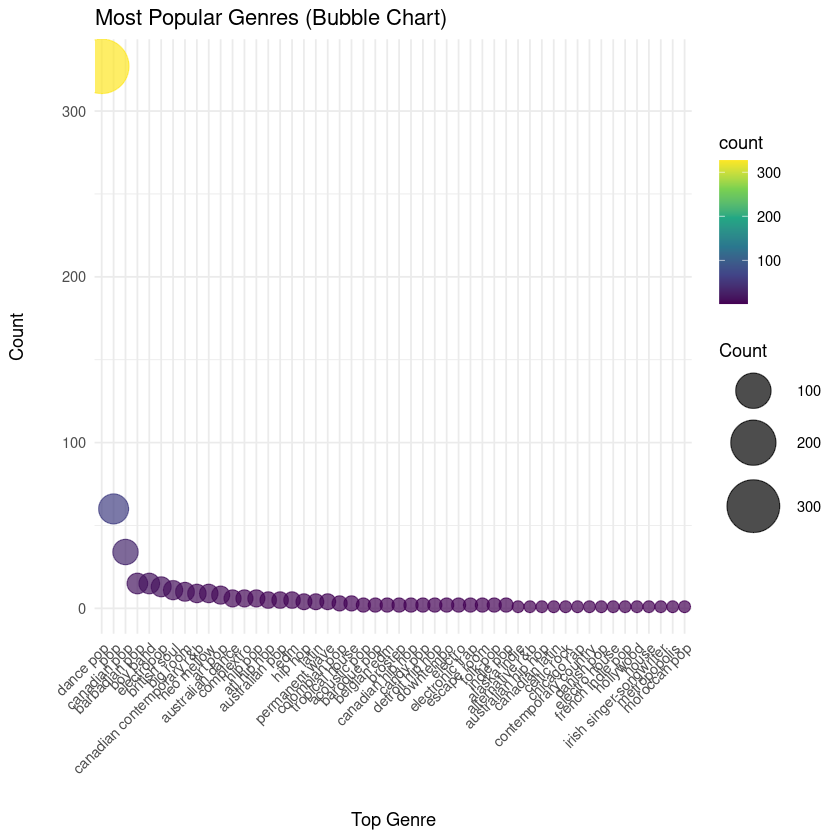

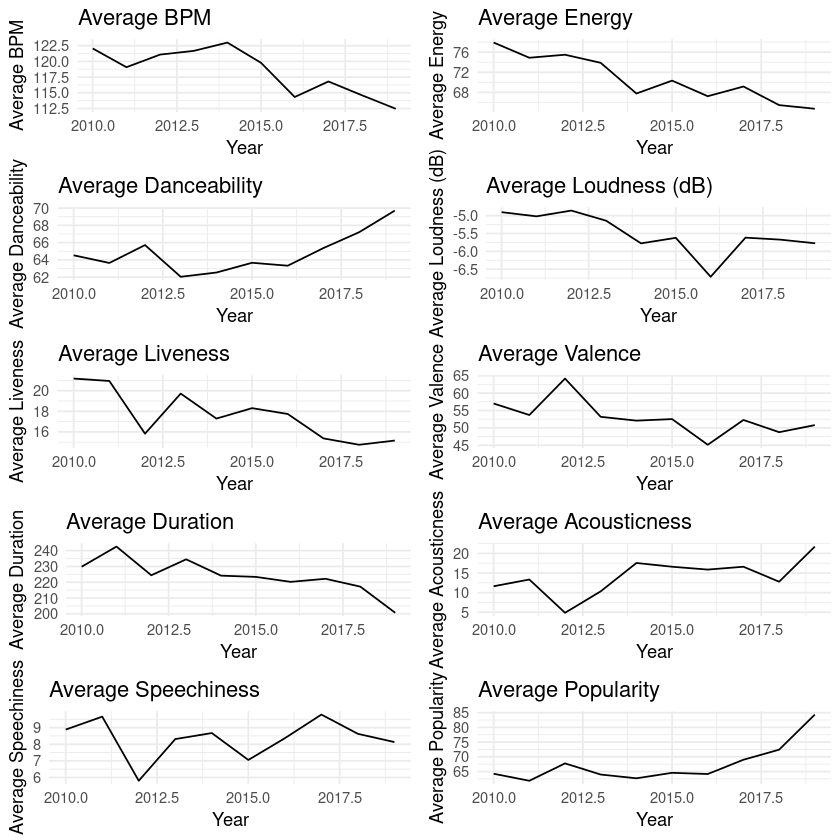

In [52]:

# Bar chart
bar_chart = ggplot(genre_popularity, aes(x = reorder(`top genre`, -count), y = count)) +
  geom_bar(stat = "identity") + theme_minimal() + 
  labs(x = "Top Genre", y = "Count", title = "Most Popular Genres") + theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave("bar_chart.png", plot = bar_chart, width = 20, height = 10)

# Bubble chart
bubble_chart = ggplot(genre_popularity, aes(x = reorder(`top genre`, -count), y = count, size = count, color = count)) +
  geom_point(alpha = 0.7) + 
  scale_size_continuous(range = c(3, 15)) +
  scale_color_viridis_c() +
  theme_minimal() +
  labs(x = "Top Genre", y = "Count", title = "Most Popular Genres (Bubble Chart)", size = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        axis.title.x = element_text(margin = margin(t = 20)),
        axis.title.y = element_text(margin = margin(r = 20)))
ggsave("bubble_chart.png", plot = bubble_chart, width = 30, height = 20)

bar_chart
bubble_chart

# Analyze trends over the years
trends = spotify %>%
  group_by(year) %>%
  summarise(
    avg_bpm = mean(bpm, na.rm = TRUE),
    avg_nrgy = mean(nrgy, na.rm = TRUE),
    avg_dnce = mean(dnce, na.rm = TRUE),
    avg_dB = mean(dB, na.rm = TRUE),
    avg_live = mean(live, na.rm = TRUE),
    avg_val = mean(val, na.rm = TRUE),
    avg_dur = mean(dur, na.rm = TRUE),
    avg_acous = mean(acous, na.rm = TRUE),
    avg_spch = mean(spch, na.rm = TRUE),
    avg_pop = mean(pop, na.rm = TRUE)
  )

# Plot trends over the years
trend_plots = list()
variables = c("avg_bpm", "avg_nrgy", "avg_dnce", "avg_dB", "avg_live", "avg_val", "avg_dur", "avg_acous", "avg_spch", "avg_pop")
titles = c("Average BPM", "Average Energy", "Average Danceability", "Average Loudness (dB)", "Average Liveness", "Average Valence", "Average Duration", "Average Acousticness", "Average Speechiness", "Average Popularity")

for (i in 1:length(variables)) {
  trend_plots[[i]] = ggplot(trends, aes(x = year, y = .data[[variables[i]]])) +
    geom_line() + theme_minimal() +
    labs(x = "Year", y = titles[i], title = titles[i])
}

# Save trend plots
for (i in 1:length(trend_plots)) {
  ggsave(paste0("trend_plot_", variables[i], ".png"), plot = trend_plots[[i]], width = 10, height = 5)
}

# Display trend plots
grid.arrange(grobs = trend_plots, ncol = 2)

# **Recommendations for Creating a Hit Song**

**Motivation**
To help you create a hit song, I analyzed the characteristics of top songs from 2010 to 2019. My goal was to identify trends and key features that make a song popular.

**Analysis Steps**
1. Genre Popularity: We identified the most popular genres.
2. Trends Over the Years: We analyzed how various musical features have changed over the years.

**Findings**
1. Most Popular Genre: The most popular genre is dance pop!.
2. Trends:
   - BPM: The average BPM has remained relatively stable.
   - Energy: Songs have become slightly more energetic over the years.
   - Danceability: Danceability has increased, making songs easier to dance to.
   - Loudness (dB): Loudness has remained stable.
   - Liveness: Liveness has decreased, indicating fewer live recordings.
   - Valence: Songs have become slightly happier.
   - Duration: The average duration of songs has decreased.
   - Acousticness: Acousticness has decreased, indicating a preference for electronic sounds.
   - Speechiness: Speechiness has remained stable.
   - Popularity: The average popularity of songs has increased.

# **Conclusions**
### Based on our analysis, here are some concrete recommendations:
### 1. Genre: Consider creating a song in the dance pop genre.
### 2. Energy and Danceability: Aim for a high energy and danceability score to make your song more engaging.
### 3. Valence: A slightly happier tone can make your song more appealing.
### 4. Duration: Keep your song's duration relatively short.
### 5. Acousticness: Opt for electronic sounds over acoustic ones.

### By following these recommendations, you can increase your chances of creating a hit song that resonates with a broad audience.
